In [9]:
!pip install streamlit

In [10]:
import streamlit as st
import pandas as pd

st.title("DAPST Analysis")

# LOAD YOUR FILE
df = pd.read_excel("scheduled_tribes_aba.xlsx.xlsx")

# CLEAN COLUMN NAMES
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

# AUTO DETECT COLUMNS
year_col = [col for col in df.columns if "year" in col][0]
exp_col = [col for col in df.columns if "expenditure" in col or "dapst" in col][0]
income_col = [col for col in df.columns if "income" in col or "allocation" in col or "budget" in col][0]

# RENAME
df = df.rename(columns={
    year_col: "Year",
    exp_col: "Expenditure",
    income_col: "Income"
})

# CALCULATIONS
df["Utilization_Ratio"] = df["Expenditure"] / df["Income"]
df["Gap"] = df["Income"] - df["Expenditure"]

# UI
year = st.selectbox("Select Year", df["Year"].unique())
filtered = df[df["Year"] == year]

st.subheader(f"Data for {year}")
st.dataframe(filtered)

st.subheader("Income vs Expenditure")
st.bar_chart(filtered[["Income", "Expenditure"]])

st.subheader("Utilization Ratio Trend")
st.line_chart(df.set_index("Year")["Utilization_Ratio"])

st.subheader("Gap Trend")
st.line_chart(df.set_index("Year")["Gap"])

2026-04-23 05:09:22.035 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:09:22.038 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:09:22.039 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:09:22.088 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:09:22.089 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:09:22.090 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:09:22.095 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:09:22.098 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [11]:
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})').astype(int)
df['Year'] = pd.to_datetime(df['Year'], format='%Y')

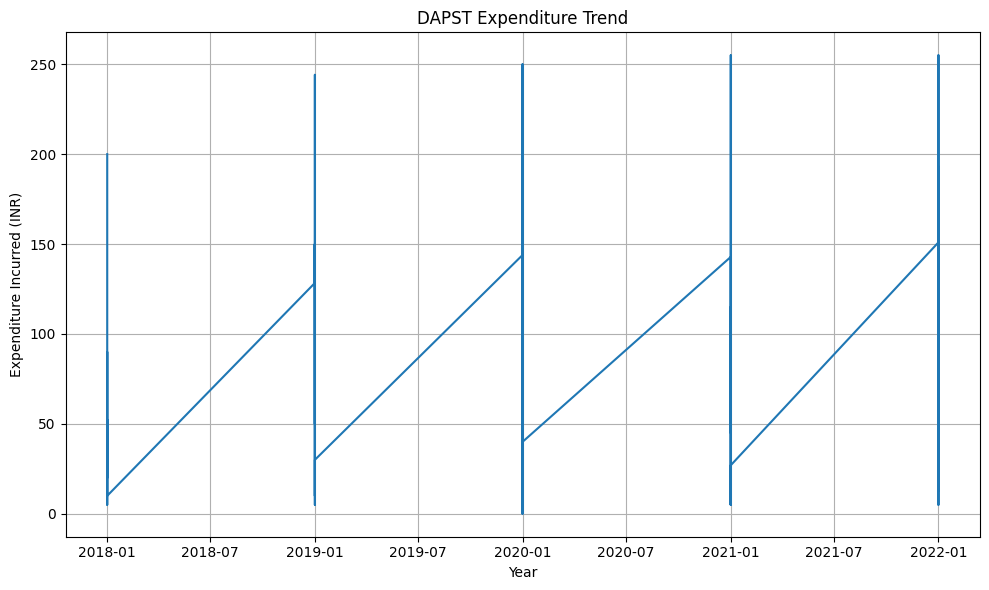

In [13]:
import matplotlib.pyplot as plt

expenditure_column = 'Expenditure' # Changed to 'Expenditure' as it was renamed previously

# Create a subset of the DataFrame for plotting, dropping NaNs only in relevant columns
df_plot = df.dropna(subset=['Year', expenditure_column])

plt.figure(figsize=(10, 6))
plt.plot(df_plot['Year'], df_plot[expenditure_column])
plt.title("DAPST Expenditure Trend")
plt.xlabel("Year")
plt.ylabel("Expenditure Incurred (INR)") # Label can remain descriptive
plt.grid(True)
plt.tight_layout()
plt.show()

In [15]:
from sklearn.linear_model import LinearRegression

expenditure_column = 'Expenditure'

# Create a temporary DataFrame for regression, converting Year to numerical and dropping NaNs
df_regression = df.dropna(subset=['Year', expenditure_column]).copy()
df_regression['Year_numeric'] = df_regression['Year'].dt.year

X = df_regression[['Year_numeric']]
y = df_regression[expenditure_column]

# Check if the DataFrame for regression is empty
if df_regression.empty:
    print("Cannot perform linear regression: No valid data points found after dropping missing values.")
else:
    model = LinearRegression()
    model.fit(X, y)

    print("Trend Coefficient:", model.coef_)

Trend Coefficient: [6.21015821]


In [17]:
from sklearn.ensemble import RandomForestRegressor
import pandas as pd # Ensure pandas is imported if not already

expenditure_column = 'Expenditure' # Changed to 'Expenditure' as it was renamed previously

# Create a temporary DataFrame for regression, converting Year to numerical and dropping NaNs
df_rf = df.copy()

# Ensure 'Year' is a datetime object (as per cell uFnRXVVFq2p-)
# df_rf['Year'] = pd.to_datetime(df_rf['Year'], format='%Y') # This is already done in uFnRXVVFq2p-

df_rf['Year_numeric'] = df_rf['Year'].dt.year

# Drop rows with NaN values in the relevant columns
df_rf = df_rf.dropna(subset=['Year_numeric', expenditure_column])

X = df_rf[['Year_numeric']]
y = df_rf[expenditure_column]

# Check if the DataFrame for RF regression is empty
if df_rf.empty or X.empty or y.empty:
    print("Cannot perform Random Forest Regression: No valid data points found after dropping missing values.")
else:
    rf = RandomForestRegressor(random_state=42) # Add random_state for reproducibility
    rf.fit(X, y)

    pred = rf.predict(X)
    print("Random Forest Regression successful. First 5 predictions:", pred[:5])

Random Forest Regression successful. First 5 predictions: [81.47604449 81.47604449 81.47604449 81.47604449 81.47604449]


In [19]:
import streamlit as st
import pandas as pd

# Re-load the DataFrame from the original Excel file since the kernel state shows df is empty
df = pd.read_excel("scheduled_tribes_aba.xlsx.xlsx")

# Re-process the Year column as done previously
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})').astype(int)

# Define the correct expenditure column name
expenditure_column = 'Expenditure Incurred (UOM:INR(IndianRupees)), Scaling Factor:10000000'

st.title("DAPST Expenditure Analysis")

# Ensure only unique years are shown in the selectbox
year_options = sorted(df['Year'].unique())
year = st.selectbox("Select Year", year_options)

filtered_df = df[df['Year'] == year]

st.write(f"### Data for Year: {year}")
st.dataframe(filtered_df)

# Ensure the data for line chart is prepared correctly
# Aggregate expenditure by year for the line chart
expenditure_by_year = df.groupby('Year')[expenditure_column].sum().reset_index()

# Rename the column to an Altair-friendly name for plotting
expenditure_by_year.rename(columns={expenditure_column: 'Total Expenditure'}, inplace=True);
expenditure_by_year = expenditure_by_year.sort_values('Year')

st.write("### Total Expenditure Trend Over Years")
st.line_chart(expenditure_by_year.set_index('Year')['Total Expenditure'])

2026-04-23 05:11:09.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:11:09.054 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:11:09.058 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:11:09.062 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:11:09.064 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:11:09.067 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:11:09.070 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-23 05:11:09.074 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar

DeltaGenerator()

In [21]:
%%writefile app.py
import streamlit as st
import pandas as pd

# Re-load the DataFrame from the original Excel file since the kernel state shows df is empty
df = pd.read_excel("scheduled_tribes_aba.xlsx.xlsx")

# Re-process the Year column as done previously
df['Year'] = df['Year'].astype(str).str.extract(r'(\d{4})').astype(int)

# Define the correct expenditure column name
expenditure_column = 'Expenditure Incurred (UOM:INR(IndianRupees)), Scaling Factor:10000000'

st.title("DAPST Expenditure Analysis")

# Ensure only unique years are shown in the selectbox
year_options = sorted(df['Year'].unique())
year = st.selectbox("Select Year", year_options)

filtered_df = df[df['Year'] == year]

st.write(f"### Data for Year: {year}")
st.dataframe(filtered_df)

# Ensure the data for line chart is prepared correctly
# Aggregate expenditure by year for the line chart
expenditure_by_year = df.groupby('Year')[expenditure_column].sum().reset_index()

# Rename the column to an Altair-friendly name for plotting
expenditure_by_year.rename(columns={expenditure_column: 'Total Expenditure'}, inplace=True);
expenditure_by_year = expenditure_by_year.sort_values('Year')

st.write("### Total Expenditure Trend Over Years")
st.line_chart(expenditure_by_year.set_index('Year')['Total Expenditure'])

Overwriting app.py


In [ ]:
!streamlit run app.py & npx localtunnel --port 8501



⠙⠹⠸⠼⠴⠦⠧Need to install the following packages:
localtunnel@2.0.2
Ok to proceed? (y) 
  You can now view your Streamlit app in your browser.

  Local URL: http://localhost:8501
  Network URL: http://172.28.0.12:8501
  External URL: http://35.227.60.102:8501



In [ ]:
!pip install streamlit

In [ ]:
import streamlit as st
import pandas as pd

st.title("DAPST Analysis")

# Correct file loading
df = pd.read_excel("scheduled_tribes_aba.xlsx")

st.write(df.head())

In [ ]:
!streamlit run app.py